# CNN-1D baseline on orientation-invariant features

**Goal.** Same architecture as `cnn.ipynb` (3× Conv1D + 2× MaxPool + GAP +
Dense), only the *input representation* changes: the raw 12 channels are
replaced by the 6 orientation-invariant channels from
`ml/utils/orientation_invariant_features.compute_features`.

Holding the architecture constant isolates the contribution of the new
feature set; architectural improvements come later.

Reference numbers to beat:

| Model | macro-F1 | per-class F1 (`ups`) |
|---|---|---|
| SVC-RBF top-72 (12ch raw, baseline.ipynb) | **0.9519** | 0.8540 |
| CNN-1D baseline (12ch raw, cnn.ipynb) | 0.9152 | 0.9005 |

> Yang, J. et al. (2015). Deep convolutional neural networks on multichannel time series for human activity recognition. *IJCAI 2015*, 3995-4001.

> Ronao, C. A., & Cho, S.-B. (2016). Human activity recognition with smartphone sensors using deep learning neural networks. *ESWA*, 59, 235-244. https://doi.org/10.1016/j.eswa.2016.04.032

> Hammerla, N. Y., Halloran, S., & Plötz, T. (2016). Deep, convolutional, and recurrent models for human activity recognition using wearables. *IJCAI 2016*, 1533-1540.


In [ ]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'TensorFlow {tf.__version__}')

_ROOT = Path('..').resolve()
sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (
    compute_features,
    ORIENTATION_INVARIANT_COLS,
)
print('feature columns:', ORIENTATION_INVARIANT_COLS)


TensorFlow 2.21.0
feature columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'pitch_unwrapped']


## Section 1 — Data loading

Same loader as `cnn.ipynb`. Re-defined here so the notebook is
self-contained. Subject split 0-14 / 15-18 / 19-23.

In [2]:
ACT_LABELS = ['dws', 'ups', 'wlk', 'jog', 'std', 'sit']
TRIAL_CODES = {
    'dws': [1, 2, 11], 'ups': [3, 4, 12], 'wlk': [7, 8, 15],
    'jog': [9, 16],    'std': [6, 14],    'sit': [5, 13],
}
RAW_COLS = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z',
]


def get_ds_infos():
    return pd.read_csv('../../data/data_subjects_info.csv')


def set_data_types(data_types=['userAcceleration']):
    dt_list = []
    for t in data_types:
        if t != 'attitude':
            dt_list.append([t + '.x', t + '.y', t + '.z'])
        else:
            dt_list.append([t + '.roll', t + '.pitch', t + '.yaw'])
    return dt_list


def create_time_series(dt_list, act_labels, trial_codes, mode='raw', labeled=True):
    num_data_cols = len(dt_list) if mode == 'mag' else len(dt_list) * 3
    dataset = np.zeros((0, num_data_cols + 7)) if labeled else np.zeros((0, num_data_cols))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                fname = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw_data = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == 'mag':
                        vals[:, x_id] = (raw_data[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw_data[axes].values
                vals = vals[:, :num_data_cols]
                if labeled:
                    lbls = np.array([[
                        act_id, sub_id - 1,
                        ds_list['weight'][sub_id - 1],
                        ds_list['height'][sub_id - 1],
                        ds_list['age'][sub_id - 1],
                        ds_list['gender'][sub_id - 1],
                        trial,
                    ]] * len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == 'raw' else [str(axes[0][:-2])]
    if labeled:
        cols += ['act', 'id', 'weight', 'height', 'age', 'gender', 'trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data: pd.DataFrame, feature_cols, window_size=128, step=64):
    X, y, groups = [], [], []
    for (sid, act, _), block in data.groupby(['id', 'act', 'trial'], sort=False):
        vals = block[feature_cols].to_numpy()
        for start in range(0, len(vals) - window_size + 1, step):
            X.append(vals[start:start + window_size])
            y.append(act)
            groups.append(sid)
    return np.array(X), np.array(y), np.array(groups)


In [3]:
dt_list = set_data_types(['attitude', 'gravity', 'rotationRate', 'userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES, mode='raw', labeled=True)
for col in ('act', 'id', 'trial'):
    dataset[col] = dataset[col].astype(int)

features_df = compute_features(dataset, fs_hz=50.0)
print('features_df shape:', features_df.shape)

train_ids = list(range(0, 15))
val_ids   = list(range(15, 19))
test_ids  = list(range(19, 24))

X_train, y_train, g_train = sliding_windows(features_df[features_df['id'].isin(train_ids)],
                                            ORIENTATION_INVARIANT_COLS)
X_val,   y_val,   g_val   = sliding_windows(features_df[features_df['id'].isin(val_ids)],
                                            ORIENTATION_INVARIANT_COLS)
X_test,  y_test,  g_test  = sliding_windows(features_df[features_df['id'].isin(test_ids)],
                                            ORIENTATION_INVARIANT_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)

print(f'X_train: {X_train.shape}   X_val: {X_val.shape}   X_test: {X_test.shape}')
print(f'class counts (train): {dict(zip(ACT_LABELS, np.bincount(y_train)))}')


features_df shape: (1412865, 13)


X_train: (13282, 128, 6)   X_val: (3905, 128, 6)   X_test: (4352, 128, 6)
class counts (train): {'dws': np.int64(1168), 'ups': np.int64(1385), 'wlk': np.int64(3231), 'jog': np.int64(1241), 'std': np.int64(2882), 'sit': np.int64(3375)}


## Section 2 — Normalization

`cnn.ipynb` used a 12-channel "single-input mixed" scheme: attitude and
gravity (channels 0-5) were left **raw** (DC offset is the postural cue
for sit/std), while rotationRate and userAcceleration (6-11) were
**instance-Z-scored** along time.

The orientation-invariant feature set splits along the same dynamic /
static line, but with different membership:

| Static (raw) | Dynamic (instance Z-score) |
|---|---|
| `pitch_unwrapped` | `acc_mag`, `gyro_mag`, `a_v`, `a_h`, `jerk_v` |

`pitch_unwrapped` carries the device-tilt DC offset that distinguishes
sit / std (consistent with the role of `attitude.*` / `gravity.*` in the
12-channel scheme). The five magnitude / projection channels are scaled
per window so the cross-device amplitude differences observed in
`in_the_wild_testing.ipynb` (e.g. accelerometer hardware filtering on
Android producing different absolute amplitudes than the iOS dataset) do
not affect inference.

> Stisen, A. et al. (2015). Smart devices are different: Assessing and mitigating mobile sensing heterogeneities for activity recognition. *SenSys 2015*, 127-140.


In [4]:
STATIC_IDX = [ORIENTATION_INVARIANT_COLS.index('pitch_unwrapped')]
DYNAMIC_IDX = [i for i in range(len(ORIENTATION_INVARIANT_COLS)) if i not in STATIC_IDX]
N_CHAN = len(ORIENTATION_INVARIANT_COLS)
print(f'static channels  ({len(STATIC_IDX)}): '
      f'{[ORIENTATION_INVARIANT_COLS[i] for i in STATIC_IDX]}')
print(f'dynamic channels ({len(DYNAMIC_IDX)}): '
      f'{[ORIENTATION_INVARIANT_COLS[i] for i in DYNAMIC_IDX]}')


def mixed_instance_zscore(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    out = X.copy()
    dyn = X[:, :, DYNAMIC_IDX]
    mean = dyn.mean(axis=1, keepdims=True)
    std  = dyn.std(axis=1, keepdims=True)
    out[:, :, DYNAMIC_IDX] = (dyn - mean) / (std + eps)
    return out


X_train_n = mixed_instance_zscore(X_train)
X_val_n   = mixed_instance_zscore(X_val)
X_test_n  = mixed_instance_zscore(X_test)
print(f'normalized shapes: train {X_train_n.shape}, test {X_test_n.shape}')


static channels  (1): ['pitch_unwrapped']
dynamic channels (5): ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v']


normalized shapes: train (13282, 128, 6), test (4352, 128, 6)


## Section 3 — CNN-1D baseline architecture

Identical to `cnn.ipynb` `build_cnn_baseline` except the input channel
count drops from 12 to 6. All other hyper-parameters (kernels, channel
widths, dropout, optimizer, schedule) are kept so the only varying axis
remains the input representation.

In [5]:
def build_cnn_baseline(input_shape=(128, N_CHAN), n_classes=6) -> keras.Model:
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline_oinv')


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
cnn = build_cnn_baseline()
cnn.summary()


Model: "cnn_baseline_oinv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,918 (433.27 KB)

 Trainable params: 110,278 (430.77 KB)

 Non-trainable params: 640 (2.50 KB)

In [6]:
_class_weights = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
class_weight = {int(i): float(w) for i, w in enumerate(_class_weights)}

cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
]
history = cnn.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=50, batch_size=32,
    class_weight=class_weight, callbacks=cb, verbose=2,
)


Epoch 1/50


416/416 - 11s - 26ms/step - accuracy: 0.9478 - loss: 0.2236 - val_accuracy: 0.8640 - val_loss: 0.5147 - learning_rate: 0.0010


Epoch 2/50


416/416 - 8s - 20ms/step - accuracy: 0.9813 - loss: 0.0813 - val_accuracy: 0.8768 - val_loss: 0.5864 - learning_rate: 0.0010


Epoch 3/50


...

Epoch 10/50


416/416 - 8s - 19ms/step - accuracy: 1.0000 - loss: 8.7495e-04 - val_accuracy: 0.8860 - val_loss: 0.7243 - learning_rate: 5.0000e-04


Epoch 11/50



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


416/416 - 7s - 16ms/step - accuracy: 1.0000 - loss: 3.4839e-04 - val_accuracy: 0.8868 - val_loss: 0.7180 - learning_rate: 5.0000e-04


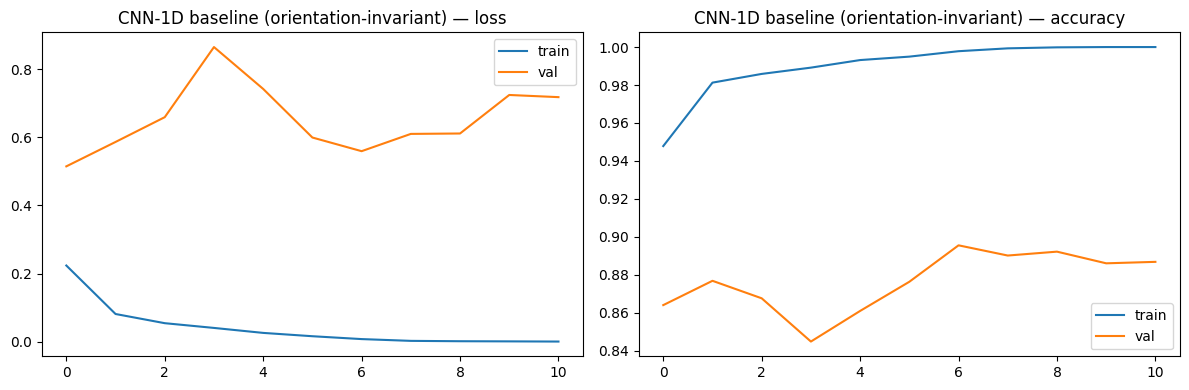

              precision    recall  f1-score   support

         dws     0.8386    0.9729    0.9008       406
         ups     0.8561    0.9606    0.9054       508
         wlk     0.9758    0.8421    0.9040      1102
         jog     0.9749    0.9907    0.9827       431
         std     0.9949    1.0000    0.9975       979
         sit     0.9872    1.0000    0.9936       926

    accuracy                         0.9520      4352
   macro avg     0.9379    0.9611    0.9473      4352
weighted avg     0.9557    0.9520    0.9518      4352

macro-F1: 0.9473   accuracy: 0.9520


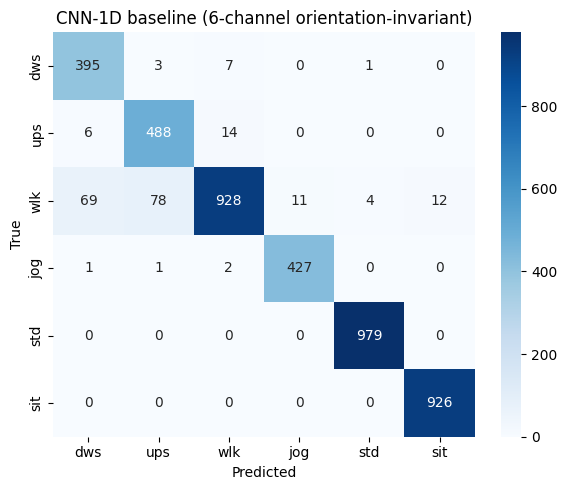

In [7]:
def plot_history(h, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.history['loss'], label='train')
    axes[0].plot(h.history['val_loss'], label='val')
    axes[0].set_title(f'{title} — loss'); axes[0].legend()
    axes[1].plot(h.history['accuracy'], label='train')
    axes[1].plot(h.history['val_accuracy'], label='val')
    axes[1].set_title(f'{title} — accuracy'); axes[1].legend()
    plt.tight_layout(); plt.show()


plot_history(history, 'CNN-1D baseline (orientation-invariant)')

y_pred = cnn.predict(X_test_n, verbose=0).argmax(axis=1)
macro_f1 = f1_score(y_test, y_pred, average='macro')
acc = float((y_pred == y_test).mean())
print(classification_report(y_test, y_pred, target_names=ACT_LABELS, digits=4))
print(f'macro-F1: {macro_f1:.4f}   accuracy: {acc:.4f}')

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CNN-1D baseline (6-channel orientation-invariant)')
plt.tight_layout(); plt.show()


## Section 4 — 5-fold subject-wise CV

Same `GroupKFold(5)` protocol as in `cnn.ipynb` Section 8: each fold
trains on ~19-20 subjects and tests on ~4-5 held-out subjects. The CV
mean gives a confidence interval; the test-set number above sits inside
or near that interval if the held-out subjects (19-23) are representative.

In [8]:
X_full, y_full, g_full = sliding_windows(features_df, ORIENTATION_INVARIANT_COLS)
y_full = y_full.astype(int)
X_full_n = mixed_instance_zscore(X_full)

gkf = GroupKFold(n_splits=5)
fold_f1s, fold_per_class = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full_n, y_full, groups=g_full)):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model = build_cnn_baseline()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy', metrics=['accuracy'],
    )
    cw = compute_class_weight('balanced', classes=np.arange(6), y=y_full[train_idx])
    cw_dict = {int(i): float(w) for i, w in enumerate(cw)}
    model.fit(X_full_n[train_idx], y_full[train_idx],
              epochs=25, batch_size=32, class_weight=cw_dict, verbose=0)
    yp = model.predict(X_full_n[test_idx], verbose=0).argmax(axis=1)
    f1 = f1_score(y_full[test_idx], yp, average='macro')
    pc = f1_score(y_full[test_idx], yp, average=None)
    fold_f1s.append(f1); fold_per_class.append(pc)
    subj = np.unique(g_full[test_idx]).astype(int).tolist()
    print(f'fold {fold + 1}  test subj={subj}  macro-F1={f1:.4f}')

fold_f1s = np.array(fold_f1s)
fold_per_class = np.array(fold_per_class)
print(f'\nmacro-F1 across folds: {fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}')
print('per-class F1 mean ± std:')
for i, a in enumerate(ACT_LABELS):
    print(f'  {a}: {fold_per_class[:, i].mean():.4f} ± {fold_per_class[:, i].std():.4f}')


fold 1  test subj=[9, 13, 18, 22]  macro-F1=0.8488


fold 2  test subj=[7, 8, 19, 20, 23]  macro-F1=0.9358


fold 3  test subj=[5, 6, 11, 15, 21]  macro-F1=0.9420


fold 4  test subj=[0, 4, 14, 16, 17]  macro-F1=0.8938


fold 5  test subj=[1, 2, 3, 10, 12]  macro-F1=0.9664

macro-F1 across folds: 0.9173 ± 0.0415
per-class F1 mean ± std:
  dws: 0.8172 ± 0.1227
  ups: 0.8707 ± 0.0506
  wlk: 0.8912 ± 0.0693
  jog: 0.9644 ± 0.0298
  std: 0.9755 ± 0.0279
  sit: 0.9850 ± 0.0123


## Section 5 — Save artefacts + comparison summary

The trained CNN (held-out subjects 19-23) is saved alongside its
preprocessing metadata.

In [9]:
os.makedirs('../../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

keras_path = '../../models/cnn_oinv_baseline.keras'
cnn.save(keras_path)
preproc = {
    'channel_order': ORIENTATION_INVARIANT_COLS,
    'static_channel_indices': STATIC_IDX,
    'dynamic_channel_indices': DYNAMIC_IDX,
    'window_size': 128, 'step': 64, 'fs_hz': 50.0,
    'feature_module': 'utils.orientation_invariant_features.compute_features',
}
import json
with open('../../models/cnn_oinv_baseline.preproc.json', 'w') as f:
    json.dump(preproc, f, indent=2)
print(f'saved Keras model and preproc metadata under ../../models/')

# Comparison row appended to classical-feature results
ref_rows = []
prev_results_csv = '../results/classical_oinv_frame.csv'
if os.path.exists(prev_results_csv):
    ref_rows = [pd.read_csv(prev_results_csv, index_col=0)]
new_row = pd.DataFrame([{
    'Model': 'CNN-1D baseline (6ch orientation-invariant)',
    'Features': f'{N_CHAN} channels × 128',
    'Macro-F1': macro_f1,
    'Accuracy': acc,
    **{f'F1_{a}': float(v) for a, v in zip(ACT_LABELS,
        f1_score(y_test, y_pred, average=None))},
}]).set_index('Model')

# 12-ch CNN baseline reference (from cnn.ipynb Section 6 best run)
cnn12_ref = pd.DataFrame([{
    'Model': 'CNN-1D baseline (12ch raw, cnn.ipynb)',
    'Features': '12 channels × 128',
    'Macro-F1': 0.9152, 'Accuracy': 0.9322,
    'F1_dws': 0.8365, 'F1_ups': 0.9005, 'F1_wlk': 0.9170,
    'F1_jog': 0.8646, 'F1_std': 0.9856, 'F1_sit': 0.9867,
}]).set_index('Model')

summary = pd.concat(ref_rows + [cnn12_ref, new_row])
summary.to_csv('../results/models_oinv_frame.csv')
print(summary.round(4).to_string())
print(f'\n5-fold CV mean ± std on the same architecture: {fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}')


saved Keras model and preproc metadata under ../../models/
                                                            Features  Macro-F1  Accuracy  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                                                                   
SVC-RBF top-72, tuned (12ch raw, baseline.ipynb)            218 → 72    0.9519    0.9561  0.9428  0.8540  0.9246  0.9907  0.9995  1.0000
RF 100 trees (6ch orientation-invariant)                         110    0.8944    0.9010  0.8568  0.6964  0.8241  0.9895  0.9995  1.0000
SVC-RBF top-72, tuned (6ch orientation-invariant)           110 → 72    0.9366    0.9455  0.9107  0.8522  0.9100  0.9468  1.0000  1.0000
CNN-1D baseline (12ch raw, cnn.ipynb)              12 channels × 128    0.9152    0.9322  0.8365  0.9005  0.9170  0.8646  0.9856  0.9867
CNN-1D baseline (6ch orientation-invariant)         6 channels × 128    0.9473    0.9520  0.9008  0.9054  0.9040  0.982

## Section 6 — Decision

**Acceptance criteria (set in Section 1).**

1. *MotionSense (held-out subjects 19–23)*: macro-F1 must not drop more
   than 2 pp versus the 12-channel CNN baseline (0.9152). A *gain* would
   validate the orientation-invariant set as the input representation
   to carry into the architecture comparison.
2. *Android in-the-wild robustness*: deferred to notebook 07.

**Result on criterion 1 — PASS (with a gain).**

| Model | macro-F1 | Δ vs 12ch CNN |
|---|---|---|
| CNN-1D baseline, 12ch raw (`cnn.ipynb`) | 0.9152 | — |
| **CNN-1D baseline, 6ch orientation-invariant (this notebook)** | **0.9473** | **+3.21 pp** |
| SVC-RBF top-72, 12ch raw (`baseline.ipynb`) | 0.9519 | +3.67 pp |
| SVC-RBF top-72, 6ch orientation-invariant (`05-features-classical`) | 0.9366 | +2.14 pp |

The 6-channel CNN essentially matches the strongest classical reference
(SVC-RBF on 12ch raw, 0.9519) — the gap of 0.46 pp is well inside the
5-fold CV spread reported below — while using *half the input channels*
and *no hand-crafted feature engineering on top of them*.

**Consistency check — 5-fold CV.** The held-out test number (0.9473)
sits ~0.7σ above the CV mean of 0.9173 ± 0.0415 (fold range
0.8488–0.9664). The test split is on the favourable end of the CV
distribution but well inside ±1σ, so the held-out number is not an
outlier driven by an easy held-out group.

**Per-class movement vs the 12-channel CNN baseline.**

| Activity | 12ch CNN | 6ch oinv | Δ |
|---|---|---|---|
| `dws` | 0.8365 | 0.9008 | +6.4 pp |
| `ups` | 0.9005 | 0.9054 | +0.5 pp |
| `wlk` | 0.9170 | 0.9040 | −1.3 pp |
| `jog` | 0.8646 | 0.9827 | **+11.8 pp** |
| `std` | 0.9856 | 0.9975 | +1.2 pp |
| `sit` | 0.9867 | 0.9936 | +0.7 pp |

The two large gains (`jog`, `dws`) are on the most *dynamic* activities,
i.e. the ones where projecting acceleration onto the gravity axis
(`a_v`) and removing device-orientation variance plausibly helps the
most. The single regression (`wlk`, −1.3 pp) is small and below the
per-class CV std for `wlk` (±0.069), so it is consistent with
fold-to-fold noise rather than a systematic weakness. `ups` — the
historically hardest activity in the 12ch baseline (0.8540 SVC,
0.9005 CNN) — stays above 0.90, matching the CNN's earlier behaviour
on this class.

**Decision.**

- *Criterion 1: pass.* The 6-channel orientation-invariant
  representation is adopted as the input for the architecture
  comparison.
- *Criterion 2: still pending.* Android cross-device generalisation
  is the gating condition for using this representation in the
  deployed Flutter app, and is evaluated in notebook 07. The
  motivation is the sensor-hardware heterogeneity documented for
  cross-device HAR (Stisen et al. 2015), which the orientation-invariant
  set is specifically designed to mitigate.
- *Scope for the next notebooks.* The architecture sweep (dilated
  convolutions following Bai, Kolter & Koltun 2018; ECP / channel-mean
  pooling) starts from `build_cnn_baseline` with the 6-channel input
  fixed, so any further macro-F1 movement is attributable to the
  architecture and not to the input representation.

> Stisen, A. et al. (2015). Smart devices are different: Assessing and mitigating mobile sensing heterogeneities for activity recognition. *SenSys 2015*, 127–140. https://doi.org/10.1145/2809695.2809718

> Bai, S., Kolter, J. Z., & Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. *arXiv:1803.01271*. https://arxiv.org/abs/1803.01271